# Metro Interstate Traffic — История данных
## 🕵️ Поймай враньё: три ловушки в данных

**Автор:** Избасар  ·  **Дата:** 2026-06-17  ·  **YDL 2026 · День 3**
**Датасет:** Metro Interstate Traffic Volume (трасса I-94, Миннеаполис–Сент-Пол), 48 204 строки × 9 колонок, 2012-10 → 2018-09.

> **Вопрос истории:** какие «очевидные» выводы про трафик на самом деле — враньё?
> Сначала два честных графика про время суток и будни, потом ловим **три ловушки**: праздник (главная), снег и дождь.


In [1]:
# Импорты, единый стиль, загрузка данных и сборка hourly / clean — одна тихая ячейка
%matplotlib inline
import os, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    'figure.dpi': 130,
    'figure.figsize': (10, 5.5),
    'font.size': 12,
    'axes.titlesize': 15,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.axisbelow': True,
})

# Палитра: один акцент, остальное приглушено
INK    = '#1a1a2e'   # тёмный текст/линии
MUTED  = '#c8ccd4'   # серый «фон-данные»
ACCENT = '#e63946'   # красный — указатель на главное
COOL   = '#457b9d'   # спокойный синий для нейтральных серий

fmt = lambda v: f'{v:,.0f}'.replace(',', ' ')   # 5709 -> "5 709"

# --- Поиск CSV: работает в Jupyter/VS Code (локально) и в Google Colab ---
CSV_NAME = 'Metro_Interstate_Traffic_Volume.csv'
candidates = [
    CSV_NAME,
    os.path.join('..', '2 Day - Data Analysis', CSV_NAME),
    os.path.join('2 Day - Data Analysis', CSV_NAME),
]
csv_path = next((p for p in candidates if os.path.exists(p)), None)
if csv_path is None:
    hits = glob.glob('**/' + CSV_NAME, recursive=True)
    csv_path = hits[0] if hits else None
if csv_path is None:
    try:                                   # Google Colab: предложить загрузку
        from google.colab import files
        up = files.upload()
        csv_path = next(iter(up))
    except Exception:
        raise FileNotFoundError(f'Положи {CSV_NAME} рядом с ноутбуком или в папку "2 Day - Data Analysis".')
print('Загружаю CSV:', csv_path)

# --- Загрузка (df = сырой, clean = после чистки сенсоров) ---
df = pd.read_csv(csv_path)                  # pandas трактует строку "None" как NaN
df['date_time'] = pd.to_datetime(df['date_time'], format='%d-%m-%Y %H:%M')

clean = df.copy()
clean.loc[clean['temp'] == 0, 'temp'] = np.nan            # битый сенсор (0 K)
clean.loc[clean['rain_1h'] > 350, 'rain_1h'] = np.nan     # нереальные осадки

# --- Честная почасовая сборка (дедуп по времени, снег через any()) ---
hourly = clean.groupby('date_time').agg(
    traffic=('traffic_volume', 'first'),
    is_snow=('weather_main', lambda x: (x == 'Snow').any()),
).reset_index()
hourly['hour']       = hourly['date_time'].dt.hour
hourly['month']      = hourly['date_time'].dt.month
hourly['is_weekend'] = hourly['date_time'].dt.weekday >= 5

print(f'Строк всего: {len(df):,}  |  честных часов: {len(hourly):,}'.replace(',', ' '))


Загружаю CSV: ../2 Day - Data Analysis/Metro_Interstate_Traffic_Volume.csv


Строк всего: 48 204  |  честных часов: 40 575


## Глава 1. Когда дорога стоит?

Начнём с самого честного: усреднённый трафик по часам суток за 6 лет.
Сразу видно «двугорбую» кривую — утренний и вечерний часы пик.


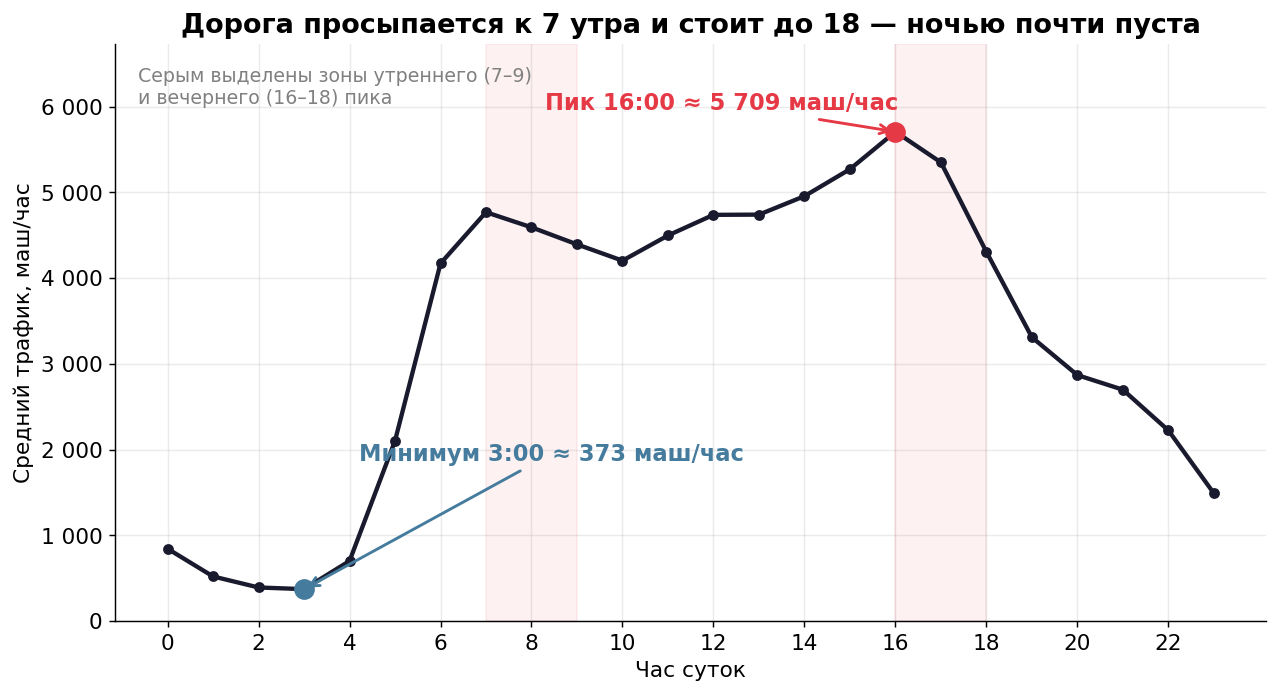

In [2]:
g = hourly.groupby('hour')['traffic'].mean()

fig, ax = plt.subplots()
ax.axvspan(7, 9,  color=ACCENT, alpha=0.07)
ax.axvspan(16, 18, color=ACCENT, alpha=0.07)
ax.plot(g.index, g.values, color=INK, lw=2.4, marker='o', ms=5, zorder=3)

peak_h, peak_v = 16, g.loc[16]
min_h,  min_v  = 3,  g.loc[3]
ax.scatter([peak_h], [peak_v], s=110, color=ACCENT, zorder=5)
ax.scatter([min_h],  [min_v],  s=110, color=COOL,   zorder=5)

ax.annotate(f'Пик 16:00 ≈ {fmt(peak_v)} маш/час',
            xy=(peak_h, peak_v), xytext=(8.3, peak_v + 250),
            fontsize=12.5, fontweight='bold', color=ACCENT,
            arrowprops=dict(arrowstyle='->', color=ACCENT, lw=1.6))
ax.annotate(f'Минимум 3:00 ≈ {fmt(min_v)} маш/час',
            xy=(min_h, min_v), xytext=(4.2, min_v + 1500),
            fontsize=12.5, fontweight='bold', color=COOL,
            arrowprops=dict(arrowstyle='->', color=COOL, lw=1.6))

ax.text(0.02, 0.96, 'Серым выделены зоны утреннего (7–9)\nи вечернего (16–18) пика',
        transform=ax.transAxes, fontsize=10.5, color='gray', va='top')
ax.set_title('Дорога просыпается к 7 утра и стоит до 18 — ночью почти пуста')
ax.set_xlabel('Час суток'); ax.set_ylabel('Средний трафик, маш/час')
ax.set_xticks(range(0, 24, 2)); ax.set_ylim(0, g.max() * 1.18)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: fmt(v)))
plt.tight_layout(); plt.show()


## Глава 2. Будни решают

Сравним усреднённый трафик в будни и в выходные.
Разрыв заметный — рабочая неделя грузит трассу сильнее.


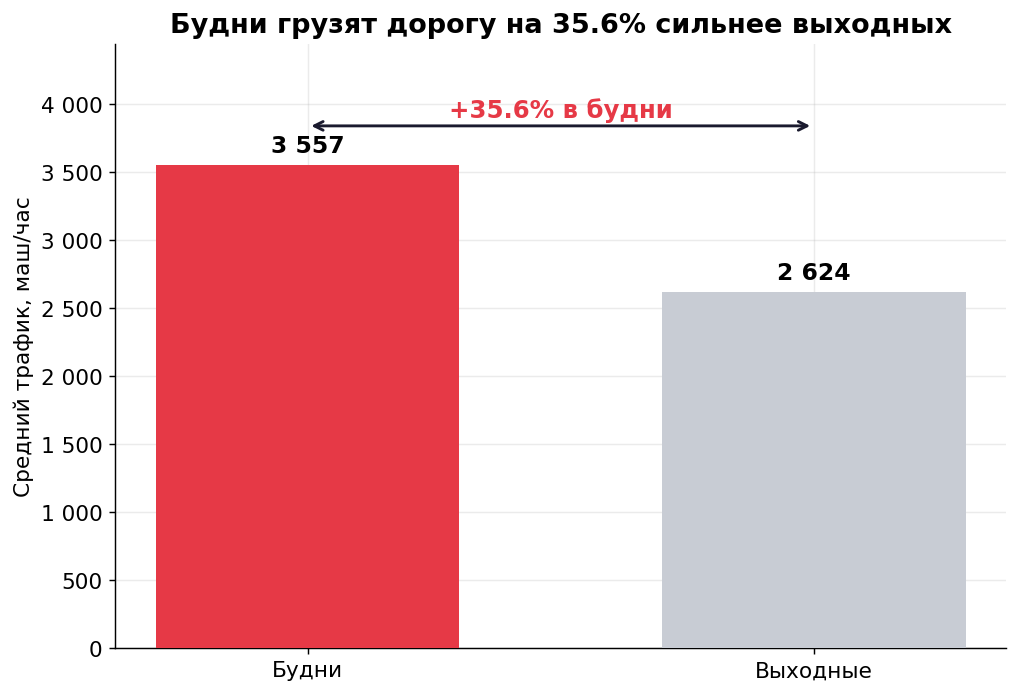

In [3]:
wk = hourly.groupby('is_weekend')['traffic'].mean()
wd, we = wk[False], wk[True]
pct = (wd / we - 1) * 100

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.bar(['Будни', 'Выходные'], [wd, we],
              color=[ACCENT, MUTED], width=0.6, zorder=3)
ax.bar_label(bars, labels=[fmt(wd), fmt(we)], padding=4,
             fontsize=13, fontweight='bold')

y = max(wd, we) * 1.08
ax.annotate('', xy=(1, y), xytext=(0, y),
            arrowprops=dict(arrowstyle='<->', color=INK, lw=1.6))
ax.text(0.5, y * 1.015, f'+{pct:.1f}% в будни',
        ha='center', fontsize=13.5, fontweight='bold', color=ACCENT)

ax.set_title(f'Будни грузят дорогу на {pct:.1f}% сильнее выходных')
ax.set_ylabel('Средний трафик, маш/час')
ax.set_ylim(0, max(wd, we) * 1.25)        # ось Y от нуля
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: fmt(v)))
plt.tight_layout(); plt.show()


## Глава 3. Ловушка №1: «в праздники дорога пустеет»

А теперь — расхожее утверждение. Сравним средний трафик в строках, помеченных как праздник, со всеми остальными.
Цифры выглядят сокрушительно убедительно… или нет?


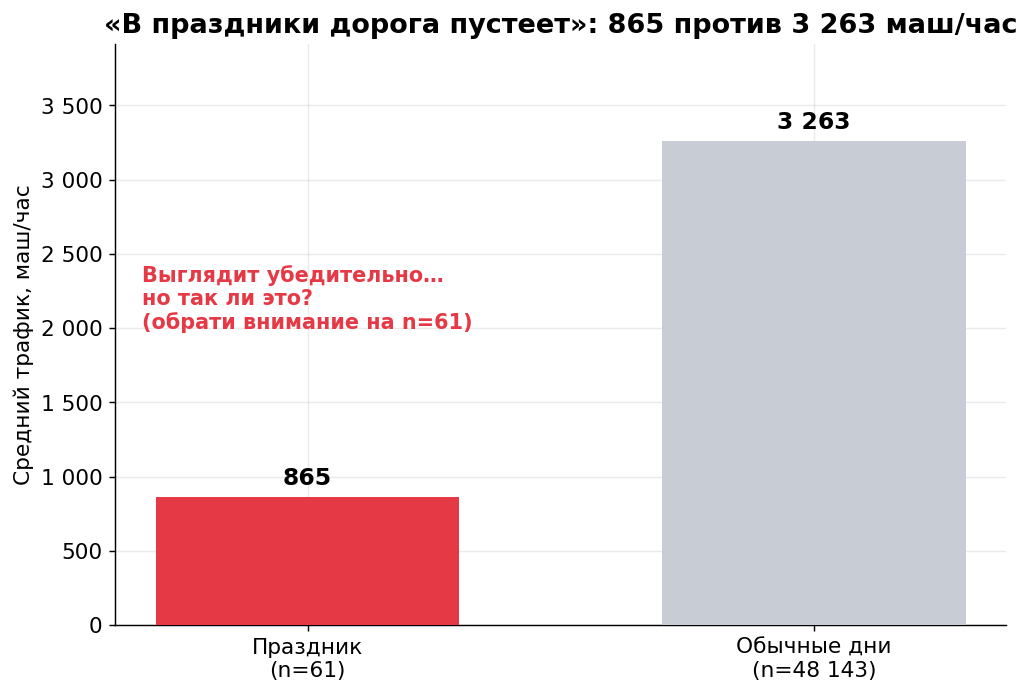

In [4]:
hol = clean['holiday'].notna()
gh = clean.groupby(hol)['traffic_volume'].agg(['mean', 'count'])
hol_mean, hol_n = gh.loc[True, 'mean'],  int(gh.loc[True, 'count'])
norm_mean, norm_n = gh.loc[False, 'mean'], int(gh.loc[False, 'count'])

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.bar([f'Праздник\n(n={hol_n})', f'Обычные дни\n(n={fmt(norm_n)})'],
              [hol_mean, norm_mean], color=[ACCENT, MUTED], width=0.6, zorder=3)
ax.bar_label(bars, labels=[fmt(hol_mean), fmt(norm_mean)], padding=4,
             fontsize=13, fontweight='bold')

ax.text(0.03, 0.62,
        'Выглядит убедительно…\nно так ли это?\n(обрати внимание на n=61)',
        transform=ax.transAxes, fontsize=11.5, color=ACCENT, fontweight='bold', va='top')
ax.set_title(f'«В праздники дорога пустеет»: {fmt(hol_mean)} против {fmt(norm_mean)} маш/час')
ax.set_ylabel('Средний трафик, маш/час')
ax.set_ylim(0, norm_mean * 1.2)           # ось Y от нуля
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: fmt(v)))
plt.tight_layout(); plt.show()


## Глава 4. Но погодите…

Прежде чем верить графику — спросим: *а в какие часы вообще стоит метка `holiday`?*
Посчитаем число помеченных строк по каждому часу суток.


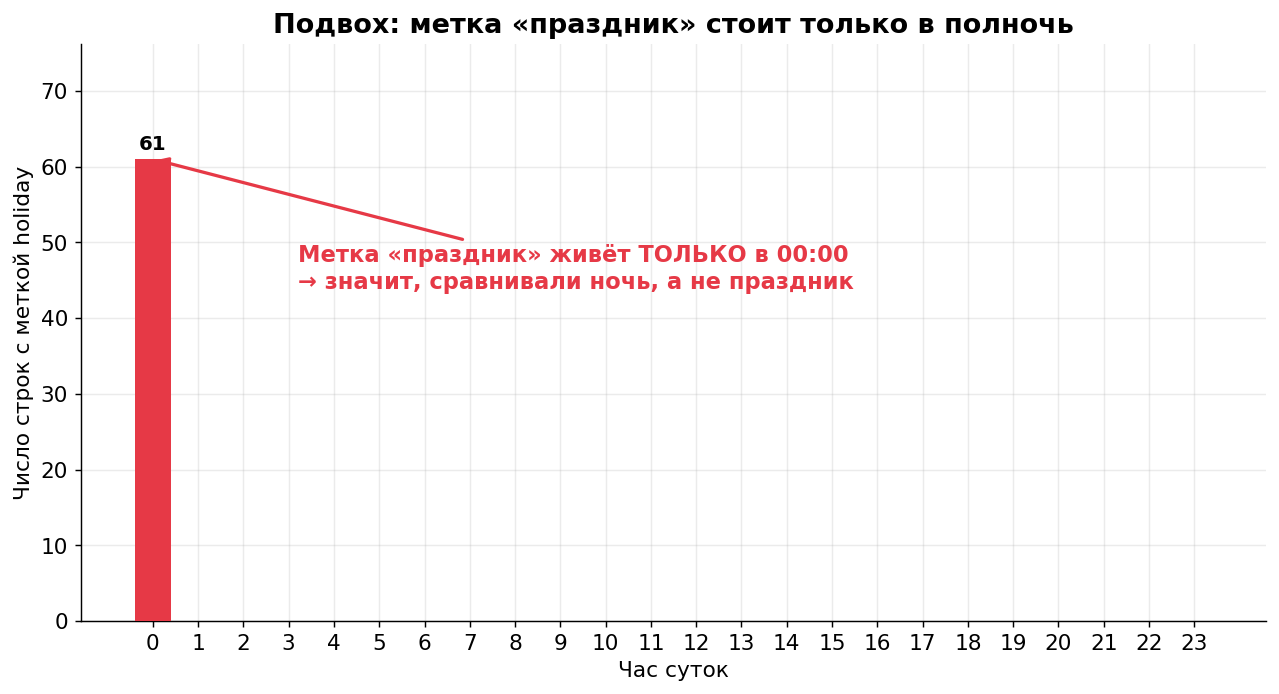

In [5]:
by_hour = (clean[hol]['date_time'].dt.hour
            .value_counts().reindex(range(24), fill_value=0).sort_index())

colors = [ACCENT if h == 0 else MUTED for h in by_hour.index]
fig, ax = plt.subplots()
bars = ax.bar(by_hour.index, by_hour.values, color=colors, width=0.8, zorder=3)
ax.bar_label(bars, labels=[str(v) if v else '' for v in by_hour.values],
             padding=3, fontsize=11, fontweight='bold')

ax.annotate('Метка «праздник» живёт ТОЛЬКО в 00:00\n→ значит, сравнивали ночь, а не праздник',
            xy=(0, by_hour.loc[0]), xytext=(3.2, by_hour.max() * 0.72),
            fontsize=12.5, fontweight='bold', color=ACCENT,
            arrowprops=dict(arrowstyle='->', color=ACCENT, lw=1.8))

ax.set_title('Подвох: метка «праздник» стоит только в полночь')
ax.set_xlabel('Час суток'); ax.set_ylabel('Число строк с меткой holiday')
ax.set_xticks(range(0, 24)); ax.set_ylim(0, by_hour.max() * 1.25)
plt.tight_layout(); plt.show()


## Глава 5. Правда про праздник

Раз метка стоит только в полночь — сравним честно:
**праздничный час** против **средней полночи по всем дням** и против **средних суток**.


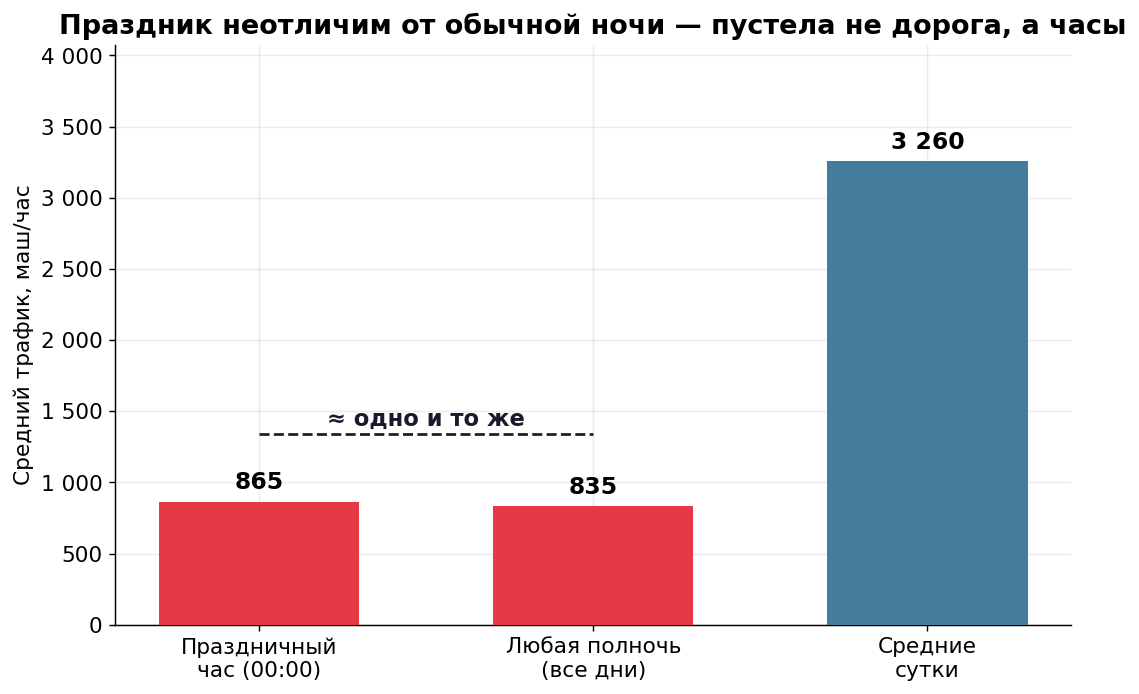

In [6]:
midnight_all = clean.loc[clean['date_time'].dt.hour == 0, 'traffic_volume'].mean()
day_all = clean['traffic_volume'].mean()

labels = ['Праздничный\nчас (00:00)', 'Любая полночь\n(все дни)', 'Средние\nсутки']
vals   = [hol_mean, midnight_all, day_all]
colors = [ACCENT, ACCENT, COOL]

fig, ax = plt.subplots(figsize=(8.5, 5.5))
bars = ax.bar(labels, vals, color=colors, width=0.6, zorder=3)
ax.bar_label(bars, labels=[fmt(v) for v in vals], padding=4,
             fontsize=13, fontweight='bold')

y = max(hol_mean, midnight_all) * 1.55
ax.plot([0, 1], [y, y], ls='--', color=INK, lw=1.5)
ax.text(0.5, y * 1.04, '≈ одно и то же', ha='center',
        fontsize=12.5, fontweight='bold', color=INK)

ax.set_title('Праздник неотличим от обычной ночи — пустела не дорога, а часы')
ax.set_ylabel('Средний трафик, маш/час')
ax.set_ylim(0, day_all * 1.25)            # ось Y от нуля
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: fmt(v)))
plt.tight_layout(); plt.show()


## Глава 6. Ловушки погоды: снег и дождь (две панели рядом)

Ещё две «очевидности», которые рассыпаются при проверке — показываем их рядом, как маленькие графики.
- **Слева — снег:** наивно глушит трафик на 9%, но снег бывает только зимой; внутри одной зимы эффект почти вдвое меньше.
- **Справа — дождь:** одна битая строка `rain_1h = 9 831 мм` раздувает средние осадки в разы.


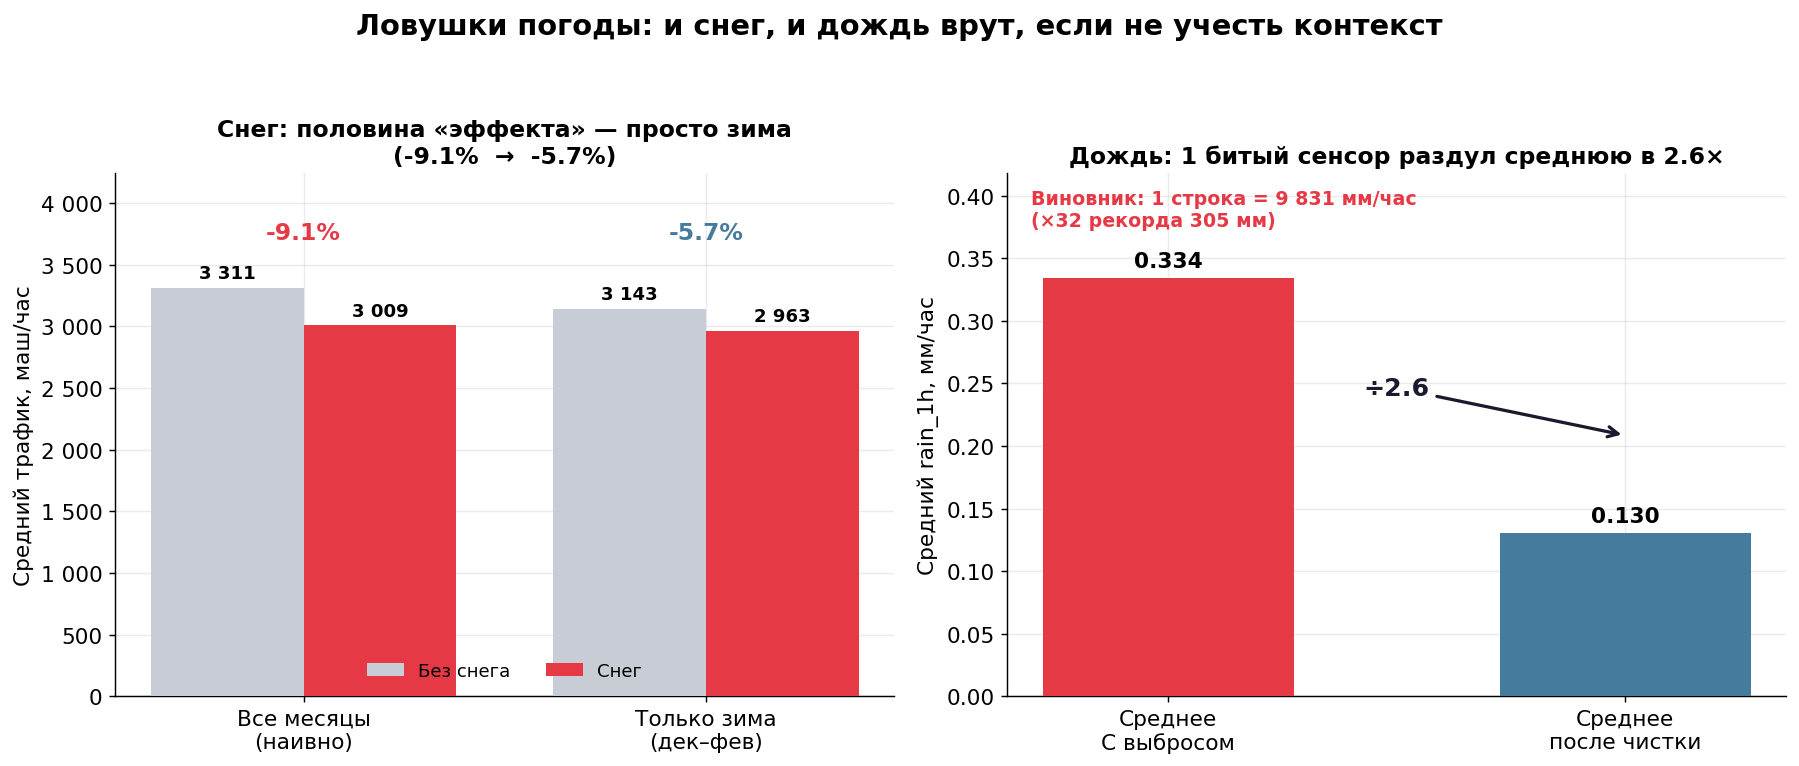

In [7]:
# --- данные: снег как confounder сезона ---
s_all = hourly.groupby('is_snow')['traffic'].mean()
win   = hourly[hourly['month'].isin([12, 1, 2])]
s_win = win.groupby('is_snow')['traffic'].mean()
naive_no, naive_sn = s_all[False], s_all[True]
win_no,   win_sn   = s_win[False], s_win[True]
pct_naive = (naive_sn / naive_no - 1) * 100
pct_win   = (win_sn   / win_no   - 1) * 100

# --- данные: дождь как один выброс ---
WORLD = 305
rain_max   = df['rain_1h'].max()
mean_with  = df['rain_1h'].mean()       # со «строкой-монстром»
mean_clean = clean['rain_1h'].mean()    # после зануления rain_1h > 350
ratio      = mean_with / mean_clean

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Ловушки погоды: и снег, и дождь врут, если не учесть контекст',
             fontsize=16, fontweight='bold')

# ── Панель 1: снег ──────────────────────────────────────────────────────────
x, w = np.arange(2), 0.38
b1 = ax1.bar(x - w/2, [naive_no, win_no], w, color=MUTED,  label='Без снега', zorder=3)
b2 = ax1.bar(x + w/2, [naive_sn, win_sn], w, color=ACCENT, label='Снег',      zorder=3)
ax1.bar_label(b1, labels=[fmt(naive_no), fmt(win_no)], padding=3, fontsize=10, fontweight='bold')
ax1.bar_label(b2, labels=[fmt(naive_sn), fmt(win_sn)], padding=3, fontsize=10, fontweight='bold')
top = max(naive_no, naive_sn)
ax1.text(0, top * 1.12, f'{pct_naive:.1f}%', ha='center', fontsize=13, fontweight='bold', color=ACCENT)
ax1.text(1, top * 1.12, f'{pct_win:.1f}%',   ha='center', fontsize=13, fontweight='bold', color=COOL)
ax1.set_title(f'Снег: половина «эффекта» — просто зима\n({pct_naive:.1f}%  →  {pct_win:.1f}%)', fontsize=13)
ax1.set_ylabel('Средний трафик, маш/час')
ax1.set_xticks(x); ax1.set_xticklabels(['Все месяцы\n(наивно)', 'Только зима\n(дек–фев)'])
ax1.set_ylim(0, top * 1.28)               # ось Y от нуля
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: fmt(v)))
ax1.legend(loc='lower center', ncol=2, frameon=False, fontsize=10)

# ── Панель 2: дождь ─────────────────────────────────────────────────────────
bars = ax2.bar(['Среднее\nС выбросом', 'Среднее\nпосле чистки'],
               [mean_with, mean_clean], color=[ACCENT, COOL], width=0.55, zorder=3)
ax2.bar_label(bars, labels=[f'{mean_with:.3f}', f'{mean_clean:.3f}'],
              padding=4, fontsize=12, fontweight='bold')
ax2.annotate(f'÷{ratio:.1f}', xy=(1, mean_clean * 1.6), xytext=(0.5, mean_with * 0.72),
             ha='center', fontsize=14, fontweight='bold', color=INK,
             arrowprops=dict(arrowstyle='->', color=INK, lw=1.8))
ax2.text(0.03, 0.97,
         f'Виновник: 1 строка = {fmt(rain_max)} мм/час\n(×{rain_max/WORLD:.0f} рекорда {WORLD} мм)',
         transform=ax2.transAxes, va='top', fontsize=10.5, color=ACCENT, fontweight='bold')
ax2.set_title(f'Дождь: 1 битый сенсор раздул среднюю в {ratio:.1f}×', fontsize=13)
ax2.set_ylabel('Средний rain_1h, мм/час')
ax2.set_ylim(0, mean_with * 1.25)         # ось Y от нуля

fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


---
# 🎯 Вывод одной фразой

> ## На I-94 трафиком правит **час суток, а не календарь**: будни на **35.6%** выше выходных, пик в 16:00 ≈ **5 709** маш/час. А три «очевидных» вывода — враньё: **праздник** низкий лишь потому, что метка стоит только в полночь (61 строка); **снег** глушит трафик вдвое слабее, чем кажется (−9.1% → −5.7%, остальное — сезон); а «ливень **9 831 мм**» — это один битый сенсор, раздувающий средние осадки в 2.6 раза.

**Главный урок:** число без контекста (час, сезон, битый датчик) — это враньё.
